# **Project Name**
### Voyage Analytics – AI-Powered Travel Intelligence Platform with End-to-End MLOps

# **Project Type : Major Project**

## Domain : Artificial Intelligence, Machine Learning and MLOps

**Industry** : Travel Analytics and Tourism Intelligence

**Project Category :**
• Predictive Analytics
• Recommendation System
• MLOps Pipeline
• API Deployment
• Dashboard Analytics

**Contribution :**
Individual Project

**Author :**
*Kumari Vrishti*

B.Tech Computer Science Engineering

# **Problem Statement**

The travel and tourism industry generates large volumes of structured and semi-structured data from bookings, airlines, hotels, travel agencies, customer interactions, and destination preferences. Despite the availability of data, decision-making in many travel systems remains reactive rather than predictive.

Travelers often face challenges such as unpredictable airfare fluctuations, inefficient accommodation discovery, lack of personalized recommendations, and limited access to actionable travel intelligence.

The objective of this project is to develop an intelligent travel analytics platform capable of integrating predictive modeling, recommendation systems, experiment tracking, model management, and deployment capabilities into a unified MLOps-driven architecture.

The platform aims to provide flight price prediction, hotel recommendation services, analytics dashboards, and production-ready API deployment while demonstrating modern Machine Learning Operations (MLOps) practices.


# **Business Objective**

The primary business objective is to build a scalable travel intelligence platform capable of transforming raw travel data into actionable insights.

The system should assist travelers, analysts, and organizations in making informed decisions through predictive analytics and recommendation systems.

Key objectives include:

• Predict flight prices using historical travel attributes.
• Recommend suitable hotels based on traveler preferences.
• Provide analytical insights through interactive dashboards.
• Track machine learning experiments using MLflow.
• Enable reproducible deployments using Docker containers.
• Expose trained models through production-ready REST APIs.
• Demonstrate an end-to-end MLOps workflow suitable for real-world environments.
`

# **Project Architecture Overview**

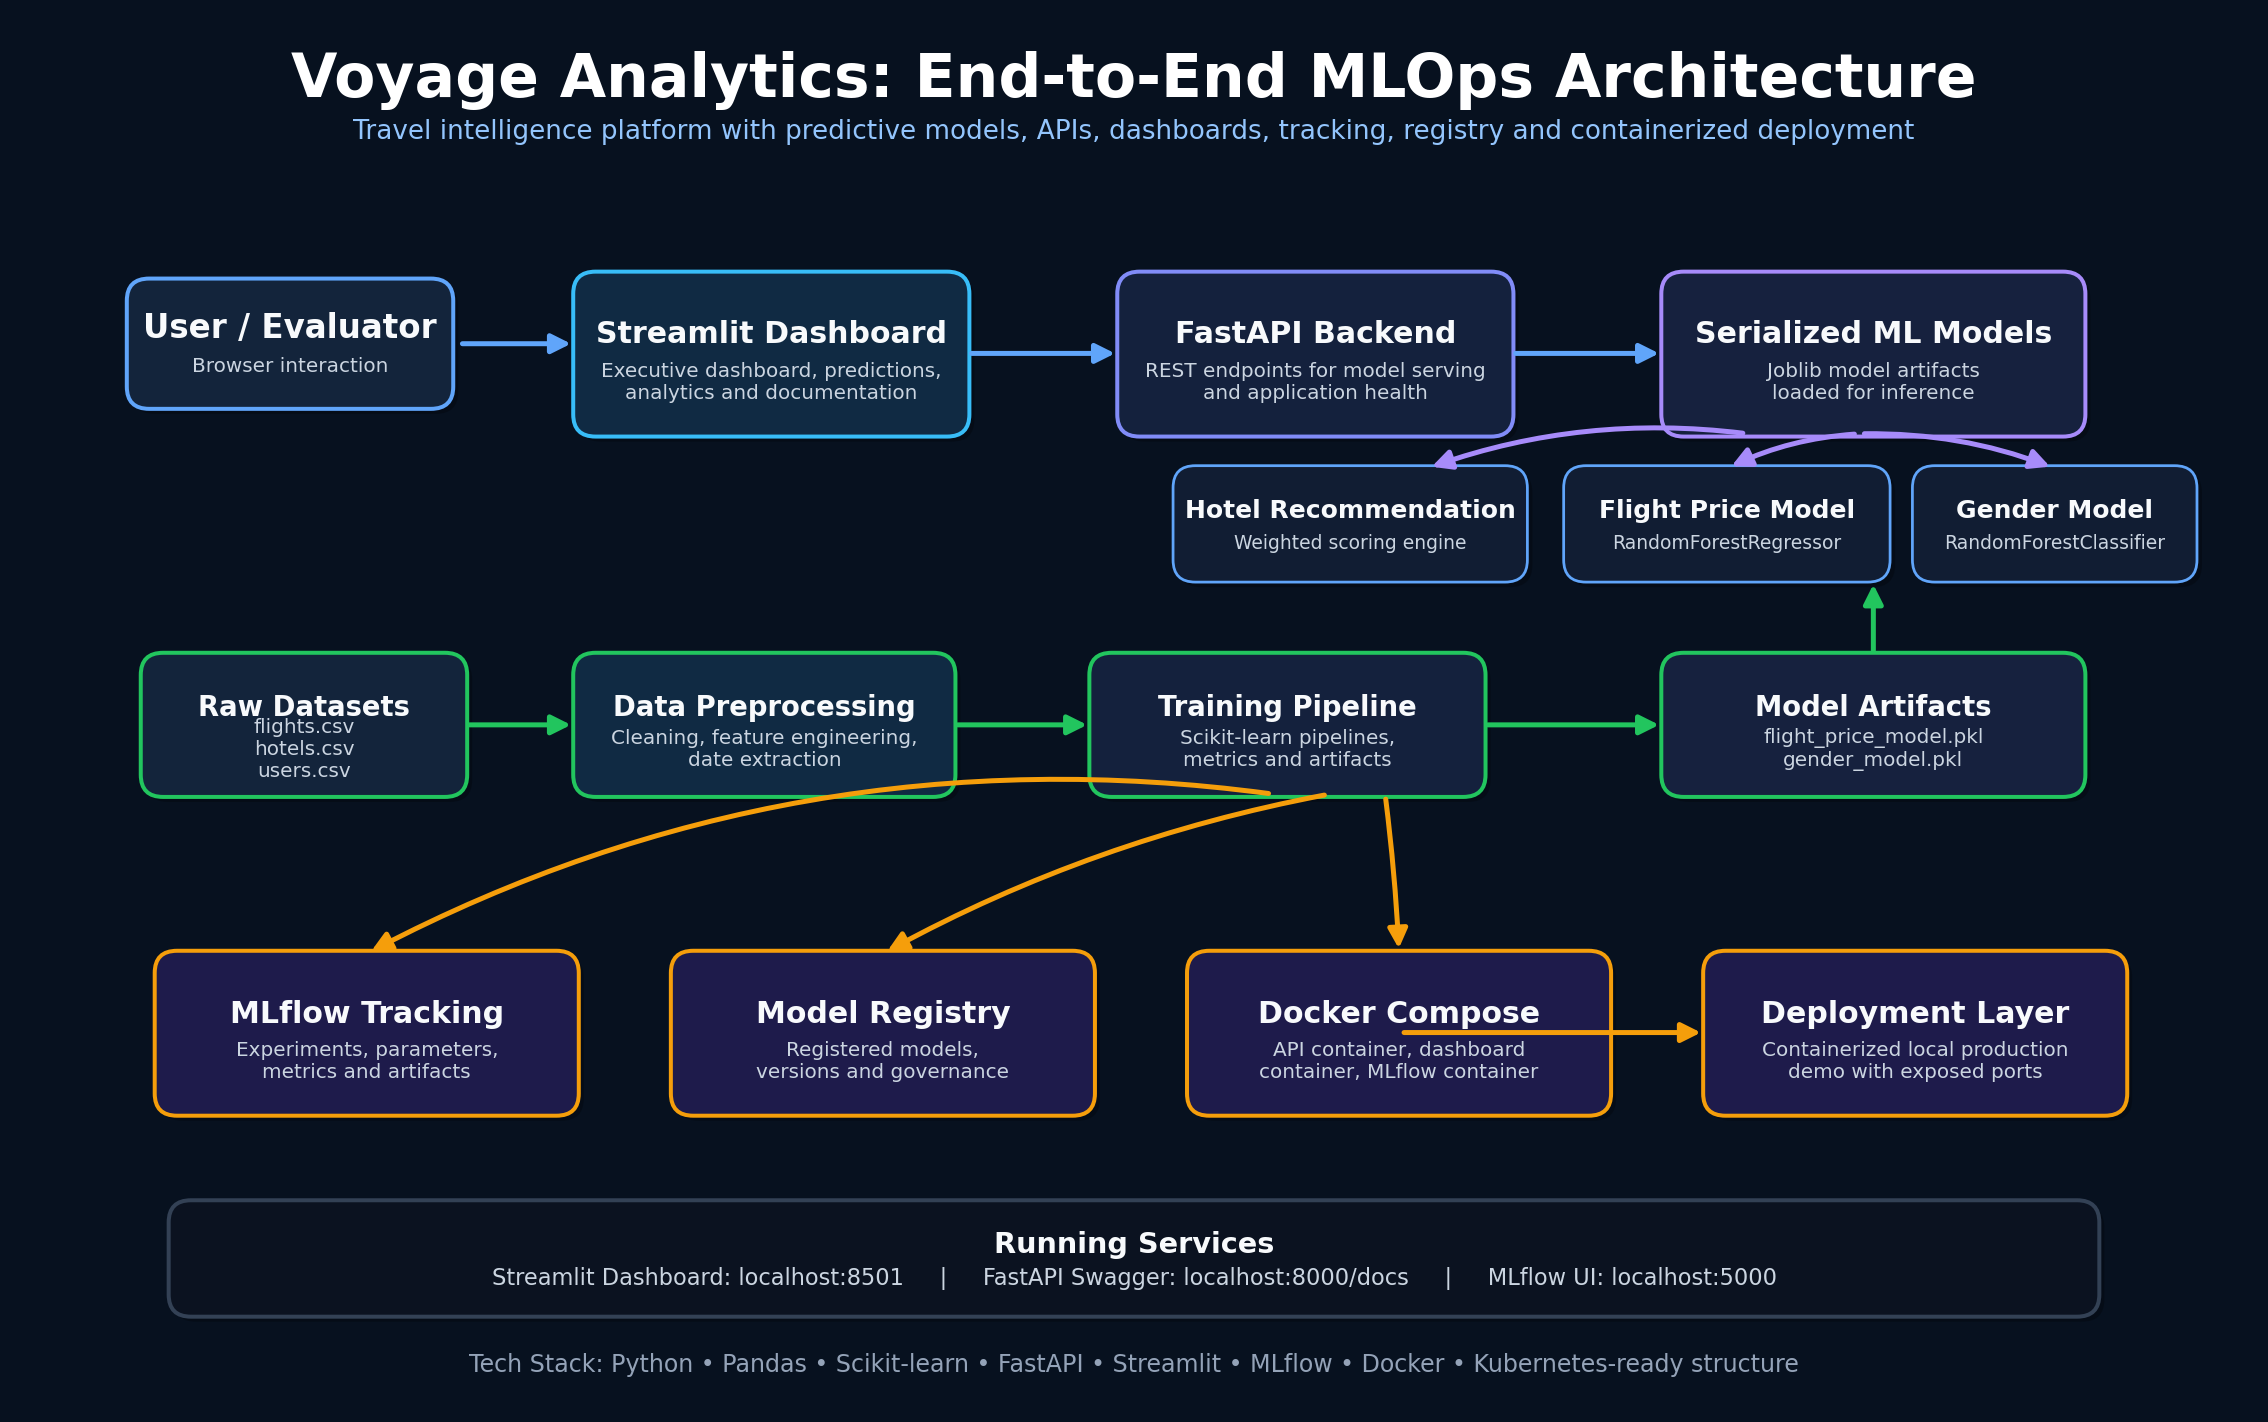

In [75]:
from IPython.display import Image
Image("/content/architecture_diagram.png")

The architecture follows a layered MLOps design consisting of:

1. Data Layer
2. Data Processing Layer
3. Machine Learning Layer
4. Model Management Layer
5. API Serving Layer
6. Analytics Dashboard Layer
7. Containerization Layer

The architecture enables seamless integration between machine learning development and deployment workflows.

# **Dataset Description**



# **Dataset Description**

## **Flight Dataset**

Table:

| Feature    | Description             |
| ---------- | ----------------------- |
| from       | Source City             |
| to         | Destination City        |
| flightType | Flight Category         |
| distance   | Distance Between Cities |
| agency     | Airline Agency          |
| month      | Travel Month            |
| day        | Travel Day              |
| time       | Travel Duration         |
| price      | Target Variable         |


## **User Dataset**
| Feature | Description     |
| ------- | --------------- |
| company | User Company    |
| age     | User Age        |
| gender  | Target Variable |


## **Import Libraries**

In [76]:
# Import core libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Utility libraries
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("default")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# **Dataset Loading**

The project uses three travel-related datasets:

1. **Flights Dataset**
   Contains flight booking records, prices, agencies, route information, distance and travel dates.

2. **Hotels Dataset**
   Contains hotel booking records, hotel names, destinations, price, stay duration and total cost.

3. **Users Dataset**
   Contains user profile information such as user code, company, name, gender and age.

In Google Colab, upload the following files:

* `flights.csv`
* `hotels.csv`
* `users.csv`

In [77]:
# Upload files in Google Colab
from google.colab import files
# Load datasets
flights = pd.read_csv("flights.csv")
hotels = pd.read_csv("hotels.csv")
users = pd.read_csv("users.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


# **Data Understanding**

**Dataset Shape**

In [78]:
# Dataset shapes
print("Flights Dataset Shape:", flights.shape)
print("Hotels Dataset Shape :", hotels.shape)
print("Users Dataset Shape  :", users.shape)

Flights Dataset Shape: (271888, 10)
Hotels Dataset Shape : (40552, 8)
Users Dataset Shape  : (1340, 5)


**Dataset Information**

In [79]:
### Dataset First View
# First five rows of flights dataset
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [80]:
# First five rows of hotels dataset
hotels.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [81]:
# First five rows of users dataset
users.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


###**Dataset Rows and Columns Count**


In [82]:
print("Flights Rows and Columns:", flights.shape)
print("Hotels Rows and Columns :", hotels.shape)
print("Users Rows and Columns  :", users.shape)

Flights Rows and Columns: (271888, 10)
Hotels Rows and Columns : (40552, 8)
Users Rows and Columns  : (1340, 5)


**## Dataset Information**


In [83]:
print("Flights Dataset Information")
print("-" * 50)
flights.info()

Flights Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [84]:
print("Hotels Dataset Information")
print("-" * 50)
hotels.info()

Hotels Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


In [85]:
print("Users Dataset Information")
print("-" * 50)
users.info()

Users Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


**Missing Values**

In [86]:
print("Missing values in flights dataset")
print(flights.isnull().sum())

Missing values in flights dataset
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64


In [87]:
print("Missing values in hotels dataset")
print(hotels.isnull().sum())

Missing values in hotels dataset
travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64


In [88]:
print("Missing values in users dataset")
print(users.isnull().sum())

Missing values in users dataset
code       0
company    0
name       0
gender     0
age        0
dtype: int64


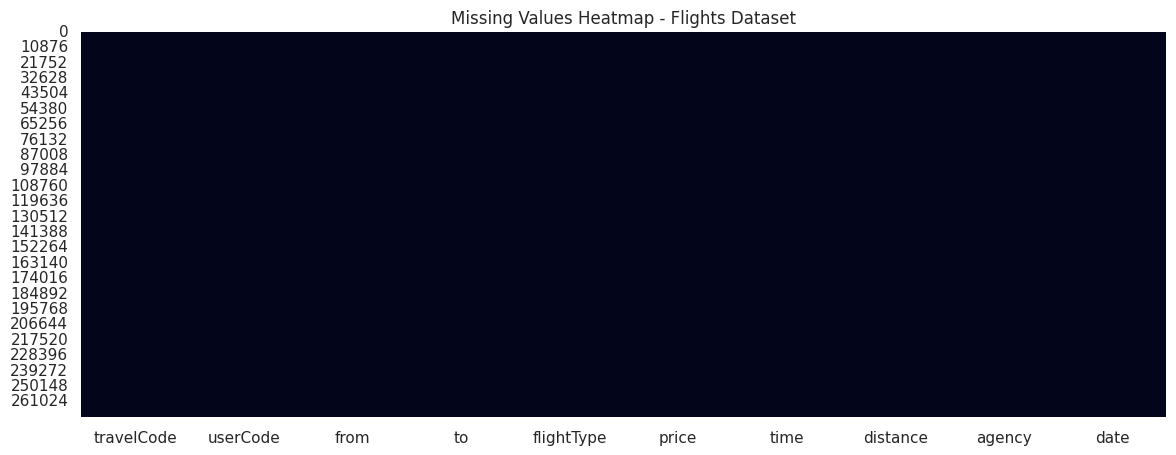

In [89]:
# Missing value visualization
plt.figure(figsize=(14, 5))
sns.heatmap(flights.isnull(), cbar=False)
plt.title("Missing Values Heatmap - Flights Dataset")
plt.show()

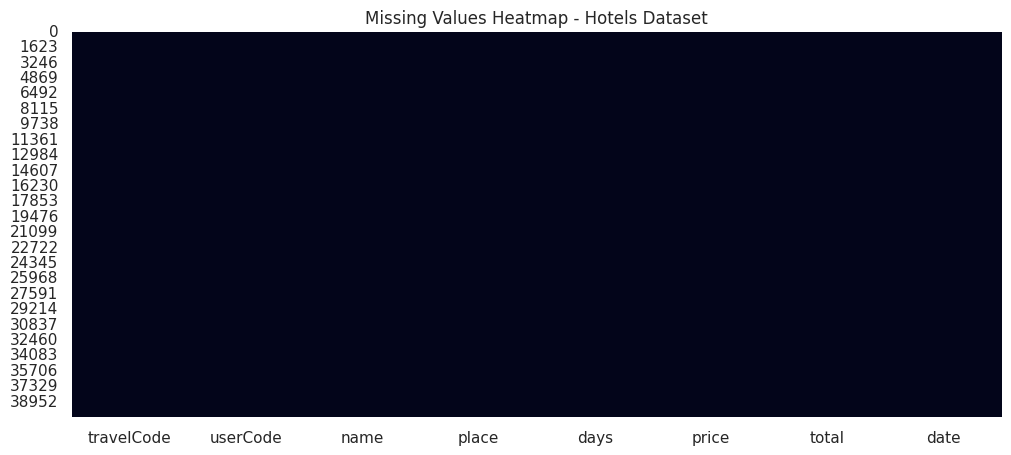

In [90]:
plt.figure(figsize=(12, 5))
sns.heatmap(hotels.isnull(), cbar=False)
plt.title("Missing Values Heatmap - Hotels Dataset")
plt.show()

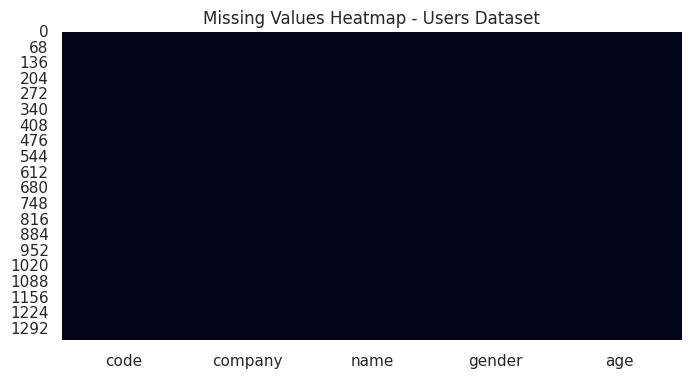

In [91]:
plt.figure(figsize=(8, 4))
sns.heatmap(users.isnull(), cbar=False)
plt.title("Missing Values Heatmap - Users Dataset")
plt.show()

## What did you know about your dataset?

The project uses travel-domain datasets containing flight transactions, hotel bookings and user profile details.

The **Flights dataset** provides information about travel routes, flight type, agency, price, time, distance and date.
The **Hotels dataset** contains hotel booking details such as destination, stay duration, price per day and total cost.
The **Users dataset** contains customer demographic information such as company, gender and age.

The datasets are suitable for building a travel analytics platform because they support:

* Price prediction
* Recommendation logic
* Customer profile analysis
* Travel behavior analysis
* MLOps model tracking and deployment demonstration

Initial inspection shows that the datasets are structured, tabular and suitable for machine learning after feature engineering.


**Duplicate Records**

In [92]:
print("Duplicate records in flights dataset:", flights.duplicated().sum())
print("Duplicate records in hotels dataset :", hotels.duplicated().sum())
print("Duplicate records in users dataset  :", users.duplicated().sum())

Duplicate records in flights dataset: 0
Duplicate records in hotels dataset : 0
Duplicate records in users dataset  : 0


## **Understanding Your Variables**

In [93]:
# Dataset columns
print("Flights Columns:")
print(flights.columns.tolist())

print("\nHotels Columns:")
print(hotels.columns.tolist())

print("\nUsers Columns:")
print(users.columns.tolist())

Flights Columns:
['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time', 'distance', 'agency', 'date']

Hotels Columns:
['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total', 'date']

Users Columns:
['code', 'company', 'name', 'gender', 'age']


In [94]:
# Statistical summary
flights.describe(include="all")

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
count,271888.000000,271888.000000,271888,271888,271888,271888.00000,271888.000000,271888.000000,271888,271888
unique,NaN,NaN,9,9,3,NaN,NaN,NaN,3,999
top,NaN,NaN,Florianopolis (SC),Florianopolis (SC),firstClass,NaN,NaN,NaN,Rainbow,09/26/2019
freq,NaN,NaN,57317,57317,116418,NaN,NaN,NaN,116752,1335
mean,67971.500000,667.505495,NaN,NaN,NaN,957.37503,1.421147,546.955535,NaN,NaN
std,39243.724665,389.523127,NaN,NaN,NaN,362.31189,0.542541,208.851288,NaN,NaN
min,0.000000,0.000000,NaN,NaN,NaN,301.51000,0.440000,168.220000,NaN,NaN
25%,33985.750000,326.000000,NaN,NaN,NaN,672.66000,1.040000,401.660000,NaN,NaN
50%,67971.500000,659.000000,NaN,NaN,NaN,904.00000,1.460000,562.140000,NaN,NaN
75%,101957.250000,1011.000000,NaN,NaN,NaN,1222.24000,1.760000,676.530000,NaN,NaN


In [95]:
hotels.describe(include="all")

,travelCode,userCode,name,place,days,price,total,date
count,40552.000000,40552.000000,40552,40552,40552.000000,40552.000000,40552.000000,40552
unique,NaN,NaN,9,9,NaN,NaN,NaN,199
top,NaN,NaN,Hotel K,Salvador (BH),NaN,NaN,NaN,10/03/2019
freq,NaN,NaN,5094,5094,NaN,NaN,NaN,404
mean,67911.794461,666.963726,NaN,NaN,2.499679,214.439554,536.229513,NaN
std,39408.199333,391.136794,NaN,NaN,1.119326,76.742305,319.331482,NaN
min,0.000000,0.000000,NaN,NaN,1.000000,60.390000,60.390000,NaN
25%,33696.750000,323.000000,NaN,NaN,1.000000,165.990000,247.620000,NaN
50%,67831.000000,658.000000,NaN,NaN,2.000000,242.880000,495.240000,NaN
75%,102211.250000,1013.000000,NaN,NaN,4.000000,263.410000,742.860000,NaN


In [96]:
users.describe(include="all")

,code,company,name,gender,age
count,1340.000000,1340,1340,1340,1340.000000
unique,NaN,5,1338,3,NaN
top,NaN,4You,Charlotte Johnson,male,NaN
freq,NaN,453,2,452,NaN
mean,669.500000,NaN,NaN,NaN,42.742537
std,386.968991,NaN,NaN,NaN,12.869779
min,0.000000,NaN,NaN,NaN,21.000000
25%,334.750000,NaN,NaN,NaN,32.000000
50%,669.500000,NaN,NaN,NaN,42.000000
75%,1004.250000,NaN,NaN,NaN,54.000000


## Variables Description

### Flights Dataset

* **travelCode**: Unique identifier for travel booking
* **userCode**: Unique identifier for user
* **from**: Source city
* **to**: Destination city
* **flightType**: Type/class of flight
* **price**: Flight ticket price
* **time**: Flight duration or time-related value
* **distance**: Travel distance
* **agency**: Flight booking agency
* **date**: Date of travel

### Hotels Dataset

* **travelCode**: Unique identifier for travel booking
* **userCode**: Unique identifier for user
* **name**: Hotel name
* **place**: Hotel location/destination
* **days**: Number of stay days
* **price**: Hotel price per day
* **total**: Total hotel cost
* **date**: Booking/travel date

### Users Dataset

* **code**: Unique user identifier
* **company**: Company associated with user
* **name**: User name
* **gender**: Gender category
* **age**: User age


In [97]:
# Check unique values for each variable

print("Unique values in Flights Dataset")
for col in flights.columns:
    print(f"{col}: {flights[col].nunique()} unique values")

print("\nUnique values in Hotels Dataset")
for col in hotels.columns:
    print(f"{col}: {hotels[col].nunique()} unique values")

print("\nUnique values in Users Dataset")
for col in users.columns:
    print(f"{col}: {users[col].nunique()} unique values")

Unique values in Flights Dataset
travelCode: 135944 unique values
userCode: 1335 unique values
from: 9 unique values
to: 9 unique values
flightType: 3 unique values
price: 490 unique values
time: 33 unique values
distance: 35 unique values
agency: 3 unique values
date: 999 unique values

Unique values in Hotels Dataset
travelCode: 40552 unique values
userCode: 1310 unique values
name: 9 unique values
place: 9 unique values
days: 4 unique values
price: 9 unique values
total: 36 unique values
date: 199 unique values

Unique values in Users Dataset
code: 1340 unique values
company: 5 unique values
name: 1338 unique values
gender: 3 unique values
age: 45 unique values


# **Data Wrangling**

## Data Wrangling Objective

The objective of data wrangling is to transform raw travel data into analysis-ready and model-ready data.

The following operations are performed:

* Creating copies of raw datasets
* Converting date columns into datetime format
* Extracting month, day and weekday features
* Creating route-level features
* Creating hotel affordability features
* Preparing datasets for visualization and machine learning


In [98]:
# Create working copies
flight_df = flights.copy()
hotel_df = hotels.copy()
user_df = users.copy()

print("Working copies created successfully.")

Working copies created successfully.


In [99]:
# Convert date columns to datetime
flight_df["date"] = pd.to_datetime(flight_df["date"], errors="coerce")
hotel_df["date"] = pd.to_datetime(hotel_df["date"], errors="coerce")

# Extract date-based features
flight_df["month"] = flight_df["date"].dt.month
flight_df["day"] = flight_df["date"].dt.day
flight_df["weekday"] = flight_df["date"].dt.day_name()

hotel_df["month"] = hotel_df["date"].dt.month
hotel_df["day"] = hotel_df["date"].dt.day
hotel_df["weekday"] = hotel_df["date"].dt.day_name()

print("Date-based features created successfully.")

Date-based features created successfully.


In [100]:
# Create route feature
flight_df["route"] = flight_df["from"].astype(str) + " → " + flight_df["to"].astype(str)

# Hotel cost efficiency feature
hotel_df["cost_per_day"] = hotel_df["total"] / hotel_df["days"]

print("Additional engineered features created successfully.")

Additional engineered features created successfully.


In [101]:
# Check updated datasets
flight_df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,month,day,weekday,route
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,9,26,Thursday,Recife (PE) → Florianopolis (SC)
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,9,30,Monday,Florianopolis (SC) → Recife (PE)
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,10,3,Thursday,Brasilia (DF) → Florianopolis (SC)
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,10,4,Friday,Florianopolis (SC) → Brasilia (DF)
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,10,10,Thursday,Aracaju (SE) → Salvador (BH)


In [102]:
hotel_df.head()

,travelCode,userCode,name,place,days,price,total,date,month,day,weekday,cost_per_day
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,2019-09-26,9,26,Thursday,313.02
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,2019-10-10,10,10,Thursday,263.41
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,2019-11-14,11,14,Thursday,263.41
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,2019-12-12,12,12,Thursday,263.41
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,2019-12-26,12,26,Thursday,313.02


## What manipulations have been done?

The following data manipulations were performed:

1. Converted date columns into datetime format.
2. Extracted month, day and weekday from travel dates.
3. Created route feature using source and destination cities.
4. Created hotel cost-per-day feature.
5. Prepared datasets for visual analysis and machine learning.

These transformations help in understanding travel behavior over time, route-level demand, hotel pricing patterns and model-ready feature representation.


# **Data Visualization, Storytelling and Experimenting with Charts**

## **Chart 1 — Distribution of Dataset Records**

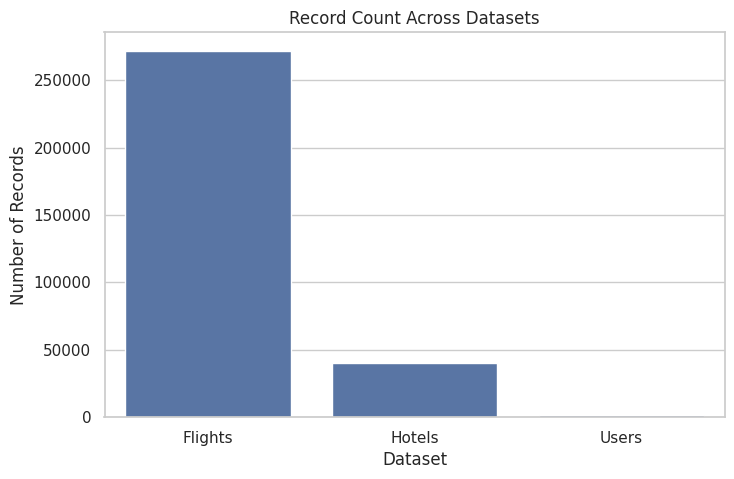

,Dataset,Records
0,Flights,271888
1,Hotels,40552
2,Users,1340


In [103]:
dataset_counts = pd.DataFrame({
    "Dataset": ["Flights", "Hotels", "Users"],
    "Records": [len(flight_df), len(hotel_df), len(user_df)]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=dataset_counts, x="Dataset", y="Records")
plt.title("Record Count Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("Number of Records")
plt.show()

dataset_counts

### Why did you pick this chart?

A bar chart is suitable for comparing the number of records across multiple datasets.

### Insights Found

The flights dataset contains the highest number of records, followed by hotels and users. This indicates that flight transactions form the largest data source in the project.

### Business Impact

Understanding dataset size helps determine which part of the system has the strongest data foundation. Since flight data is the largest, flight price prediction becomes the most reliable primary ML module.


## **Chart 2 — Flight Price Distribution**

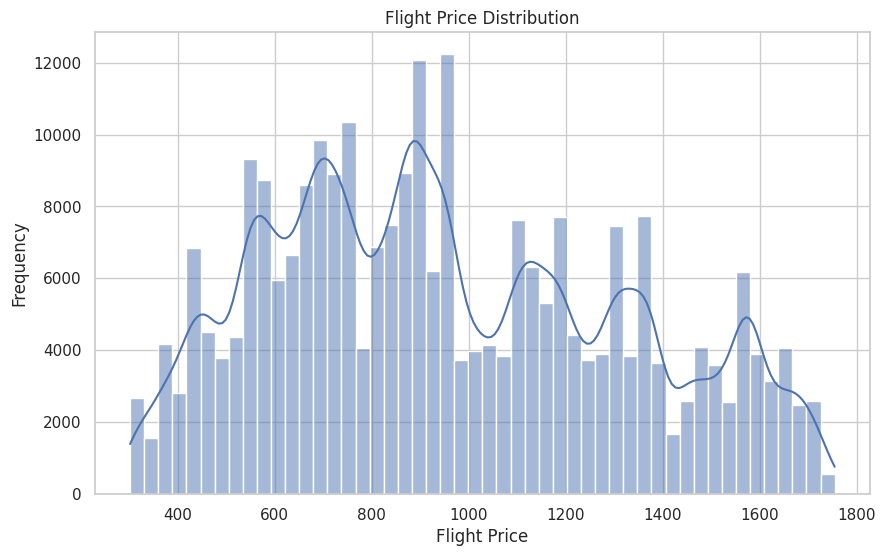

In [104]:
plt.figure(figsize=(10, 6))
sns.histplot(flight_df["price"], bins=50, kde=True)
plt.title("Flight Price Distribution")
plt.xlabel("Flight Price")
plt.ylabel("Frequency")
plt.show()

### Why did you pick this chart?

A histogram is used to understand the distribution of numerical data. It helps identify skewness, spread and pricing concentration.

### Insights Found

Flight prices show how most tickets are distributed across pricing ranges. The chart helps identify whether most tickets are low-cost, mid-range or premium.

### Business Impact

This insight helps travel platforms understand pricing behavior and build better fare prediction systems.


## **Chart 3 — Average Flight Price by Agenc**

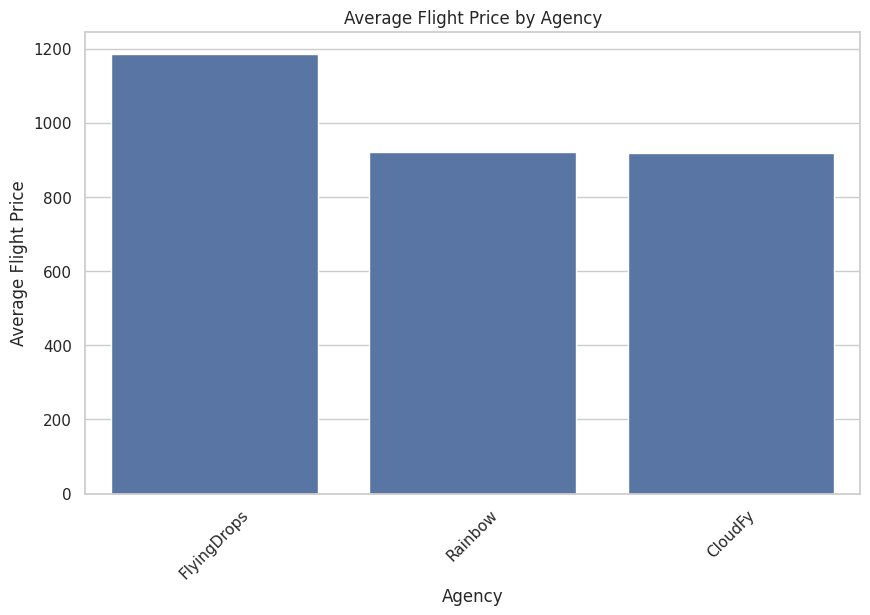

,agency,price
0,FlyingDrops,1186.160378
1,Rainbow,919.780760
2,CloudFy,918.896483


In [105]:
agency_price = (
    flight_df.groupby("agency")["price"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=agency_price, x="agency", y="price")
plt.title("Average Flight Price by Agency")
plt.xlabel("Agency")
plt.ylabel("Average Flight Price")
plt.xticks(rotation=45)
plt.show()

agency_price

### Why did you pick this chart?

A bar chart is appropriate for comparing average prices across travel agencies.

### Insights Found

Different agencies may have different average price levels. Some agencies may appear premium while others may offer relatively affordable pricing.

### Business Impact

This insight can help customers choose agencies based on affordability and help businesses analyze competitive pricing.


# **Chart 4 — Flight Type vs Price**

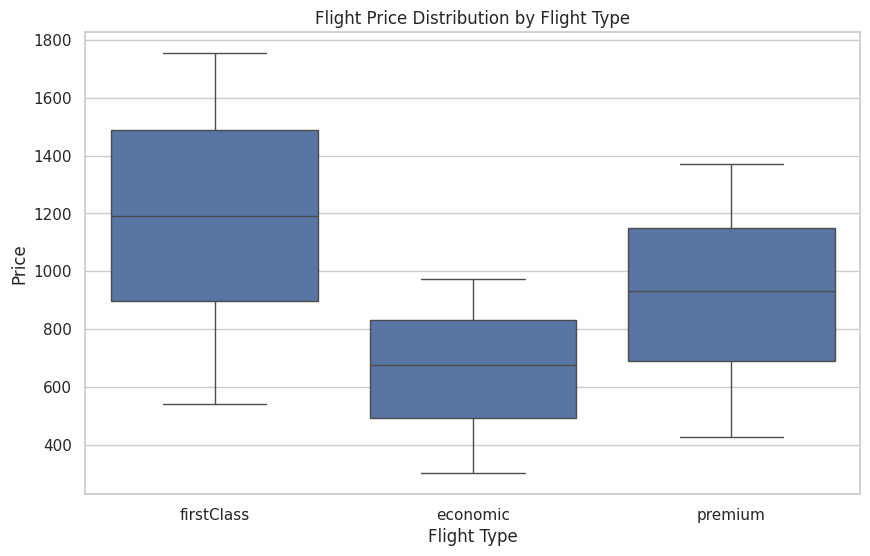

In [106]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=flight_df, x="flightType", y="price")
plt.title("Flight Price Distribution by Flight Type")
plt.xlabel("Flight Type")
plt.ylabel("Price")
plt.show()

### Why did you pick this chart?

A box plot is useful to compare price distribution across flight categories. It shows median, spread and possible outliers.

### Insights Found

Flight type affects pricing distribution. Premium or upgraded flight types may show higher median prices compared to basic flight types.

### Business Impact

Flight type can be an important feature for flight price prediction.


## **Chart 5 — Top 10 Travel Routes by Demand**

In [170]:
top_routes = (
    flight_df["route"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_routes.columns = ["Route", "Booking Count"]

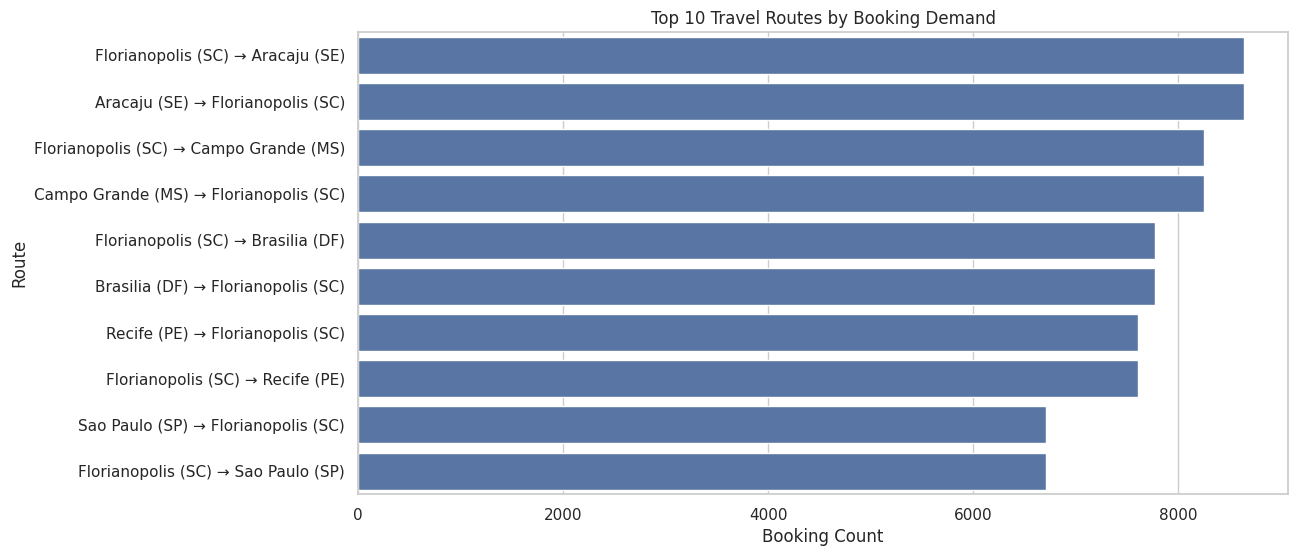

,Route,Booking Count
0,Florianopolis (SC) → Aracaju (SE),8643
1,Aracaju (SE) → Florianopolis (SC),8643
2,Florianopolis (SC) → Campo Grande (MS),8253
3,Campo Grande (MS) → Florianopolis (SC),8253
4,Florianopolis (SC) → Brasilia (DF),7779
5,Brasilia (DF) → Florianopolis (SC),7779
6,Recife (PE) → Florianopolis (SC),7609
7,Florianopolis (SC) → Recife (PE),7609
8,Sao Paulo (SP) → Florianopolis (SC),6717
9,Florianopolis (SC) → Sao Paulo (SP),6717


In [107]:
top_routes = (
    flight_df["route"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_routes.columns = ["Route", "Booking Count"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_routes, y="Route", x="Booking Count")
plt.title("Top 10 Travel Routes by Booking Demand")
plt.xlabel("Booking Count")
plt.ylabel("Route")
plt.show()

top_routes

### Why did you pick this chart?

A horizontal bar chart is useful when category names are long, such as travel routes.

### Insights Found

The chart identifies the most frequently booked routes in the dataset.

### Business Impact

High-demand routes can be prioritized for pricing optimization, promotional offers and route-specific recommendations.


## **Chart 6 — Distance vs Flight Price**

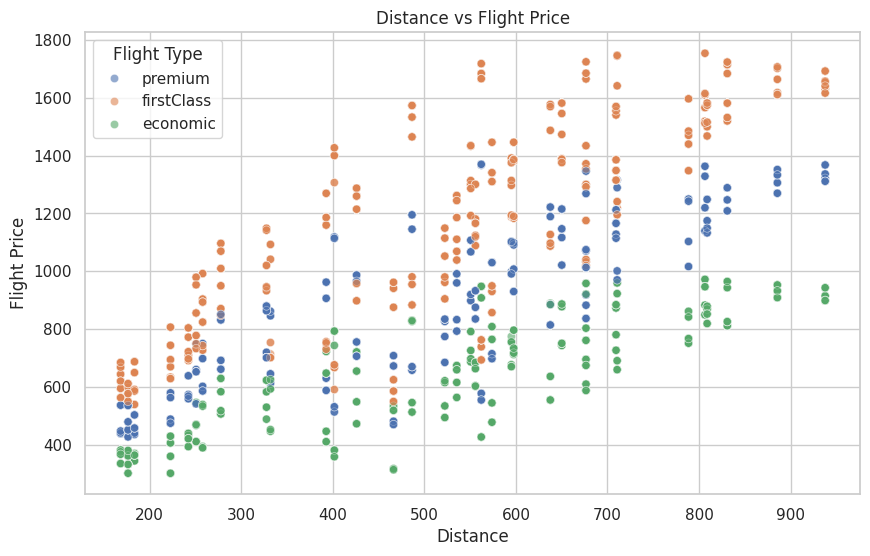

In [108]:
sample_flights = flight_df.sample(min(8000, len(flight_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_flights,
    x="distance",
    y="price",
    hue="flightType",
    alpha=0.6
)
plt.title("Distance vs Flight Price")
plt.xlabel("Distance")
plt.ylabel("Flight Price")
plt.legend(title="Flight Type")
plt.show()

### Why did you pick this chart?

A scatter plot is used to study the relationship between two numerical variables: distance and price.

### Insights Found

Flight distance is expected to influence flight price. Longer distances may generally lead to higher prices, though pricing may also depend on agency, route and flight type.

### Business Impact

Distance is a useful predictive feature for flight price modeling.


## **Chart 7 — Monthly Average Flight Price Trend**

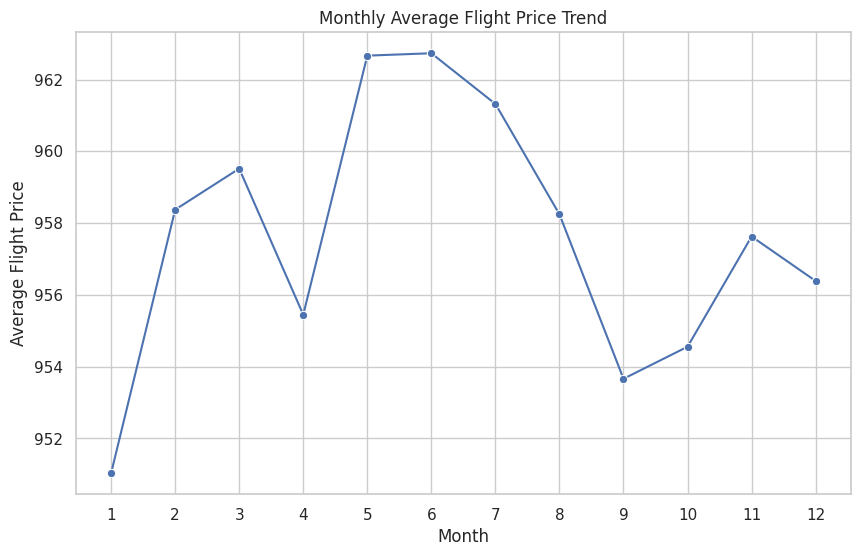

,month,price
0,1,951.030196
1,2,958.375553
2,3,959.520161
3,4,955.448870
4,5,962.668626
5,6,962.735349
6,7,961.322445
7,8,958.246613
8,9,953.662784
9,10,954.556268


In [109]:
monthly_price = (
    flight_df.groupby("month")["price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_price, x="month", y="price", marker="o")
plt.title("Monthly Average Flight Price Trend")
plt.xlabel("Month")
plt.ylabel("Average Flight Price")
plt.xticks(range(1, 13))
plt.show()

monthly_price

### Why did you pick this chart?

A line chart is suitable for showing ordered trends across months.

### Insights Found

The chart shows whether average flight prices vary across months. Seasonal pricing patterns can be observed from this trend.

### Business Impact

Travel platforms can use monthly pricing trends for seasonal fare prediction and campaign planning.


## **Chart 8 — Hotel Price by Destination**



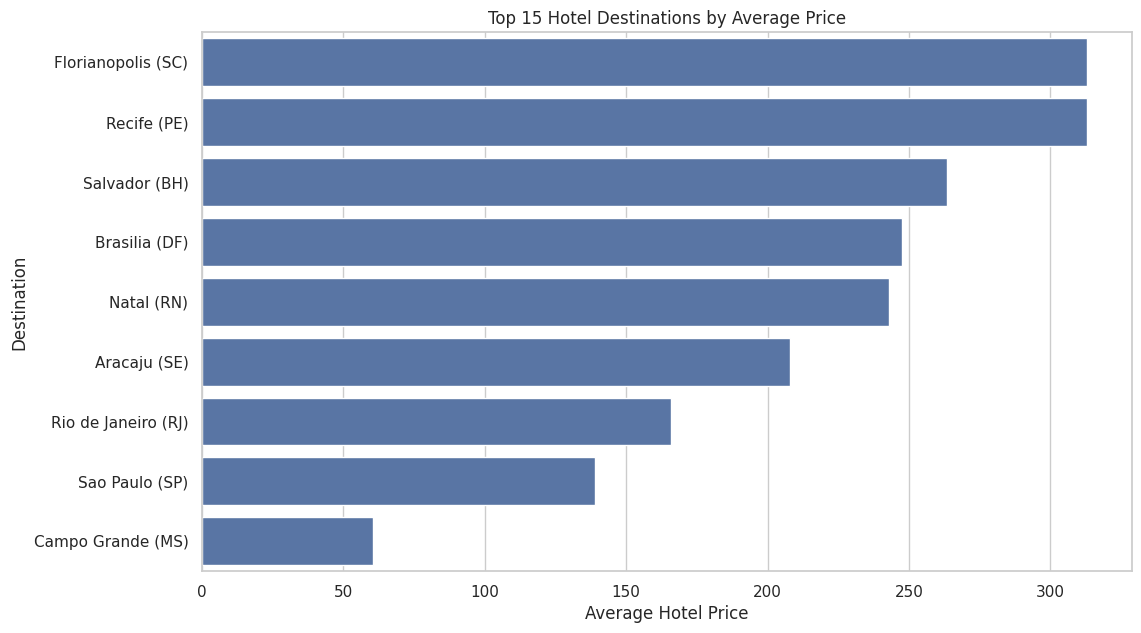

,place,price
0,Florianopolis (SC),313.02
1,Recife (PE),312.83
2,Salvador (BH),263.41
3,Brasilia (DF),247.62
4,Natal (RN),242.88
5,Aracaju (SE),208.04
6,Rio de Janeiro (RJ),165.99
7,Sao Paulo (SP),139.10
8,Campo Grande (MS),60.39


In [110]:
hotel_place_price = (
    hotel_df.groupby("place")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 7))
sns.barplot(data=hotel_place_price, y="place", x="price")
plt.title("Top 15 Hotel Destinations by Average Price")
plt.xlabel("Average Hotel Price")
plt.ylabel("Destination")
plt.show()

hotel_place_price

### Why did you pick this chart?

A horizontal bar chart is effective for ranking destinations by average hotel price.

### Insights Found

Some destinations have higher average hotel prices, indicating premium travel locations or expensive accommodation markets.

### Business Impact

This insight supports budget-aware hotel recommendation and destination-level pricing analysis.


## **Chart 9 — Hotel Stay Days Distribution**

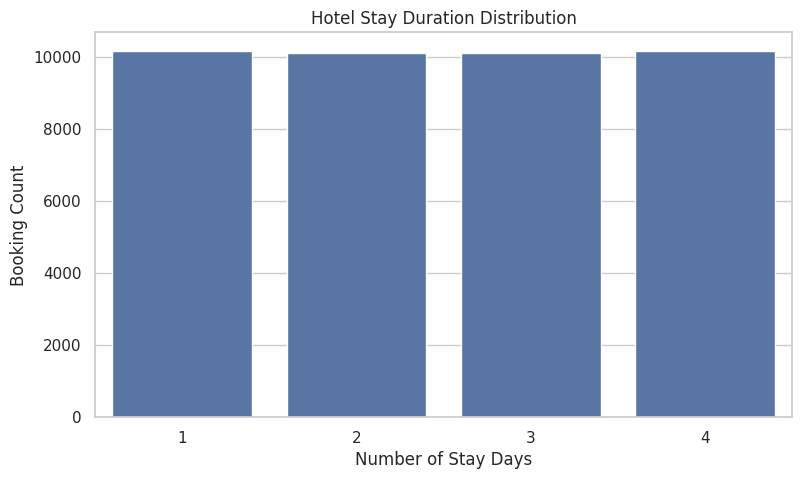

In [111]:
plt.figure(figsize=(9, 5))
sns.countplot(data=hotel_df, x="days")
plt.title("Hotel Stay Duration Distribution")
plt.xlabel("Number of Stay Days")
plt.ylabel("Booking Count")
plt.show()

### Why did you pick this chart?

A count plot is used to show the frequency of stay durations.

### Insights Found

The chart shows the most common hotel stay durations among users.

### Business Impact

Travel platforms can use this insight to design packages for common stay durations.


# **Chart 10 — User Age Distribution**

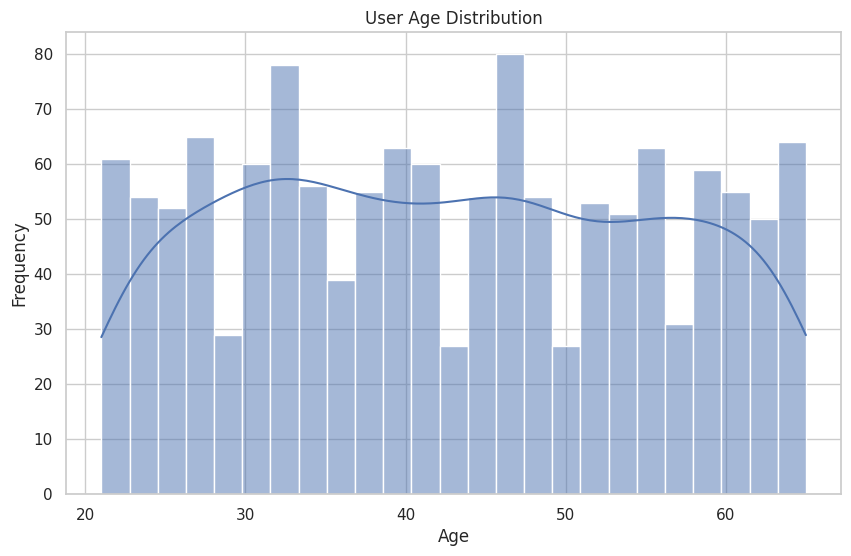

In [112]:
plt.figure(figsize=(10, 6))
sns.histplot(user_df["age"], bins=25, kde=True)
plt.title("User Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Why did you pick this chart?

A histogram is suitable for understanding the distribution of user ages.

### Insights Found

The chart shows the dominant age groups present in the user base.

### Business Impact

Age distribution can support user segmentation and personalized travel recommendations.


## **Chart 11 — Gender Distribution**

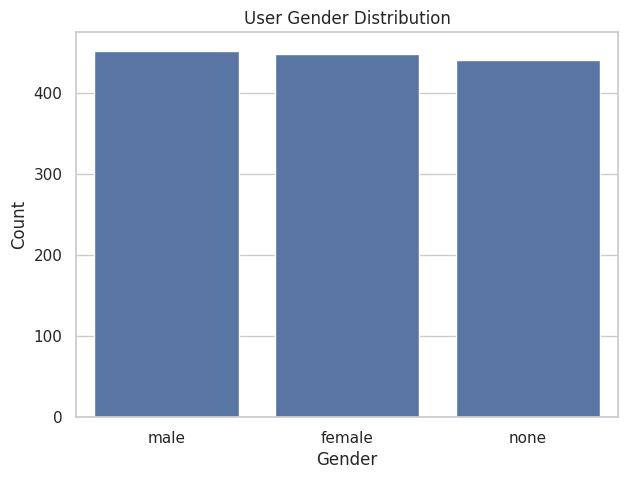

,Gender,Count
0,male,452
1,female,448
2,none,440


In [113]:
gender_counts = user_df["gender"].value_counts().reset_index()
gender_counts.columns = ["Gender", "Count"]

plt.figure(figsize=(7, 5))
sns.barplot(data=gender_counts, x="Gender", y="Count")
plt.title("User Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

gender_counts

### Why did you pick this chart?

A bar chart is suitable for comparing user count across gender categories.

### Insights Found

The chart shows the gender composition of the user dataset.

### Business Impact

User profile distribution can help understand customer segmentation, although sensitive features should be handled carefully in production systems.


## **Chart 12 — Correlation Heatmap for Flight Numerical Features**

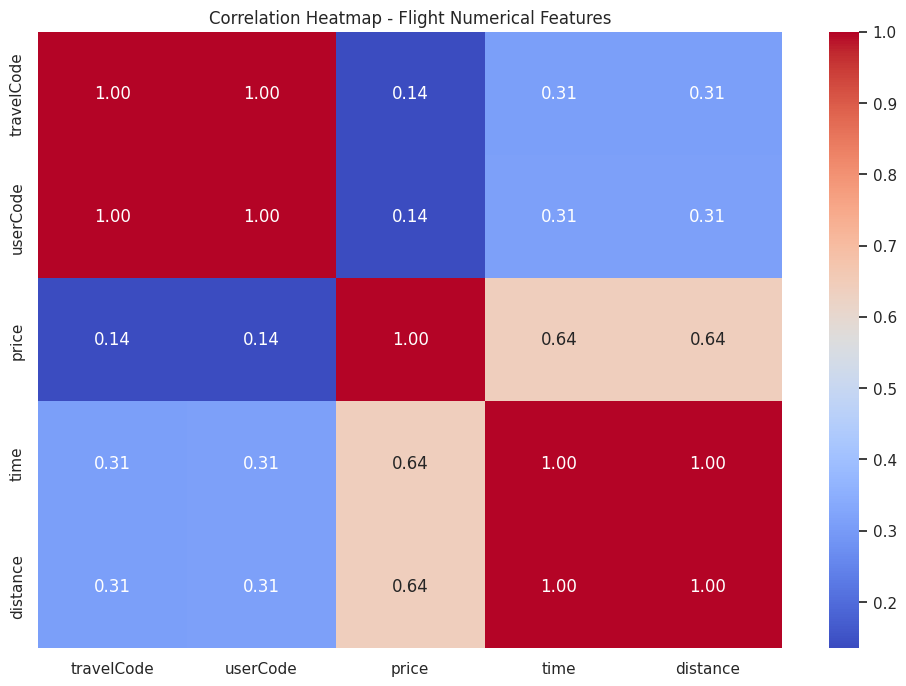

In [114]:
flight_numeric = flight_df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
sns.heatmap(flight_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Flight Numerical Features")
plt.show()

### Why did you pick this chart?

A correlation heatmap helps identify relationships between numerical variables.

### Insights Found

The heatmap shows how numerical flight variables such as price, time and distance are related.

### Business Impact

Correlation analysis helps identify useful predictive features and detect redundant variables.


## **Chart 13 — Average Hotel Cost by Month**

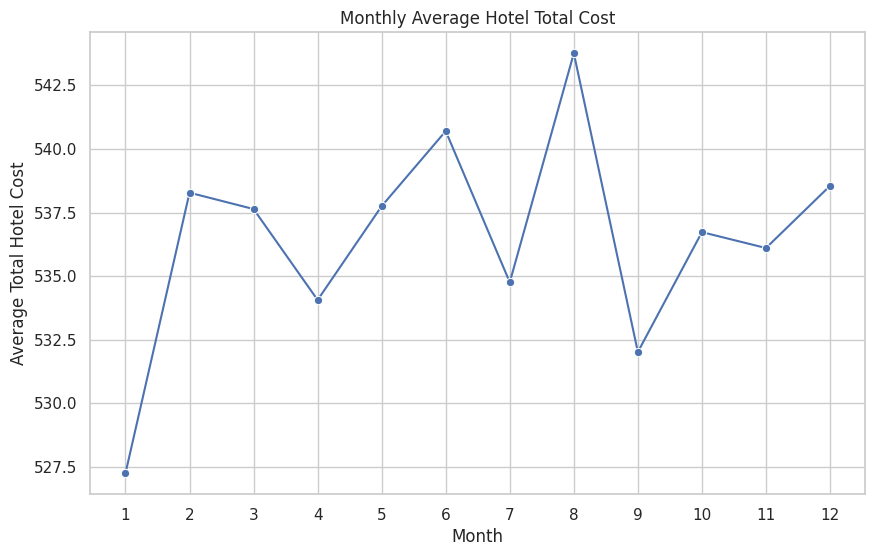

,month,total
0,1,527.252130
1,2,538.279321
2,3,537.635556
3,4,534.062164
4,5,537.750690
5,6,540.700238
6,7,534.758051
7,8,543.759244
8,9,532.017951
9,10,536.728899


In [115]:
monthly_hotel_price = (
    hotel_df.groupby("month")["total"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_hotel_price, x="month", y="total", marker="o")
plt.title("Monthly Average Hotel Total Cost")
plt.xlabel("Month")
plt.ylabel("Average Total Hotel Cost")
plt.xticks(range(1, 13))
plt.show()

monthly_hotel_price

### Why did you pick this chart?

A line chart is useful to analyze monthly hotel cost trends.

### Insights Found

Hotel booking costs may vary across months depending on demand, seasonality and destination popularity.

### Business Impact

This insight can help build seasonal hotel pricing strategies.


## **Chart 14 — Top Companies by User Count**

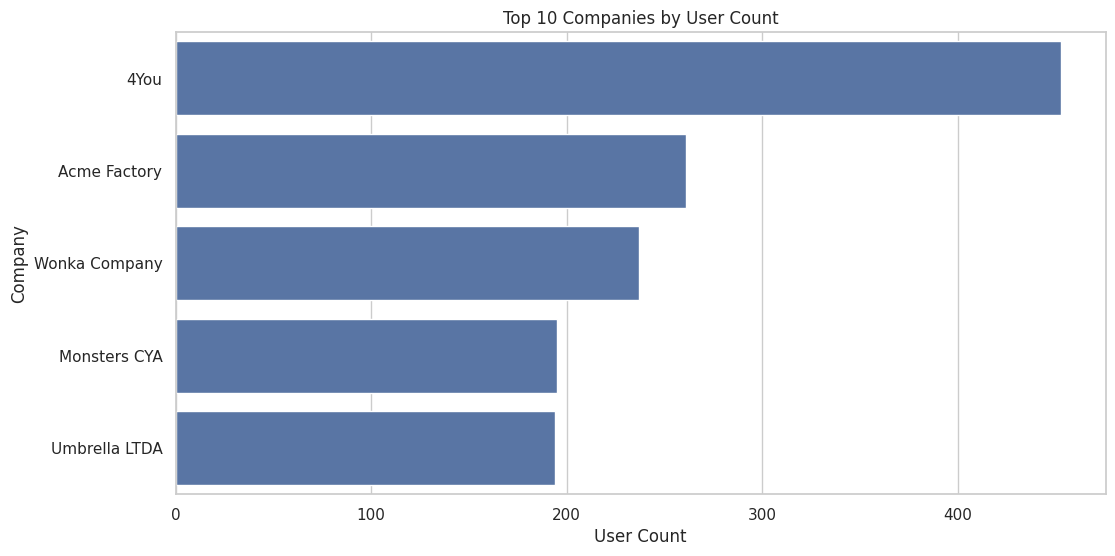

,Company,User Count
0,4You,453
1,Acme Factory,261
2,Wonka Company,237
3,Monsters CYA,195
4,Umbrella LTDA,194


In [116]:
top_companies = (
    user_df["company"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_companies.columns = ["Company", "User Count"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_companies, y="Company", x="User Count")
plt.title("Top 10 Companies by User Count")
plt.xlabel("User Count")
plt.ylabel("Company")
plt.show()

top_companies

### Why did you pick this chart?

A horizontal bar chart helps compare user counts across companies.

### Insights Found

Some companies contribute more users than others in the dataset.

### Business Impact

Company-based segmentation can support corporate travel analytics and B2B travel recommendations.


# **Summary of EDA Findings**

The exploratory data analysis provides the following insights:

Flight records form the largest part of the dataset.
Flight price varies across agencies, routes, flight types and distance.
Certain routes have higher travel demand.
Hotel prices differ significantly across destinations.
Stay duration distribution helps understand common travel patterns.
User age and gender distribution support customer segmentation.
Monthly trends provide useful seasonality information.
Numerical correlation helps identify important model features.

# **Business Insights from EDA**

## **Based on the analysis:**

Flight price prediction should use route, agency, flight type, distance and date features.
Hotel recommendation should consider destination, budget and stay duration.
High-demand routes can be prioritized for business planning.
Expensive destinations can be treated as premium travel locations.
User demographic analysis can support personalization, but sensitive attributes must be used responsibly.
The project has sufficient structure to support machine learning and MLOps deployment.Business Insights from EDA

Based on the analysis:

Flight price prediction should use route, agency, flight type, distance and date features.
Hotel recommendation should consider destination, budget and stay duration.
High-demand routes can be prioritized for business planning.
Expensive destinations can be treated as premium travel locations.
User demographic analysis can support personalization, but sensitive attributes must be used responsibly.
The project has sufficient structure to support machine learning and MLOps deployment.

# 5. Feature Engineering & Data Pre-processing

The purpose of feature engineering is to convert raw business data into machine-learning-ready features.

For this project, feature engineering is performed separately for:

1. Flight Price Prediction
2. Gender Classification
3. Hotel Recommendation Engine

The deployment-ready version of this project also uses these processed features inside the FastAPI backend, Streamlit dashboard, MLflow tracking pipeline and Dockerized environment.


In [117]:
# Final check of prepared datasets
print("Flight Data Shape:", flight_df.shape)
print("Hotel Data Shape :", hotel_df.shape)
print("User Data Shape  :", user_df.shape)

Flight Data Shape: (271888, 14)
Hotel Data Shape : (40552, 12)
User Data Shape  : (1340, 5)


In [118]:
# Selecting features for flight price prediction

flight_features = [
    "from",
    "to",
    "flightType",
    "time",
    "distance",
    "agency",
    "month",
    "day"
]

flight_target = "price"

X_flight = flight_df[flight_features]
y_flight = flight_df[flight_target]

print("Flight feature matrix shape:", X_flight.shape)
print("Flight target shape:", y_flight.shape)

Flight feature matrix shape: (271888, 8)
Flight target shape: (271888,)


In [119]:
# Feature groups for flight model

flight_categorical_features = [
    "from",
    "to",
    "flightType",
    "agency"
]

flight_numeric_features = [
    "time",
    "distance",
    "month",
    "day"
]

print("Categorical Features:", flight_categorical_features)
print("Numerical Features  :", flight_numeric_features)

Categorical Features: ['from', 'to', 'flightType', 'agency']
Numerical Features  : ['time', 'distance', 'month', 'day']


# **Flight Price Prediction Model**

## Flight Model Preprocessing Strategy

The flight price prediction model contains both categorical and numerical variables.

### Categorical Variables

* Source city
* Destination city
* Flight type
* Agency

These variables are encoded using **OneHotEncoder**.

### Numerical Variables

* Flight time
* Distance
* Month
* Day

These variables are scaled using **StandardScaler**.

A **ColumnTransformer** is used to combine both preprocessing steps into a single machine learning pipeline.


In [120]:
# Flight preprocessing pipeline

flight_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical_encoder",
            OneHotEncoder(handle_unknown="ignore"),
            flight_categorical_features
        ),
        (
            "numeric_scaler",
            StandardScaler(),
            flight_numeric_features
        )
    ]
)

print("Flight preprocessing pipeline created successfully.")

Flight preprocessing pipeline created successfully.


In [121]:
# Train-test split for flight price prediction

X_flight_train, X_flight_test, y_flight_train, y_flight_test = train_test_split(
    X_flight,
    y_flight,
    test_size=0.20,
    random_state=42
)

print("Flight training shape:", X_flight_train.shape)
print("Flight testing shape :", X_flight_test.shape)

Flight training shape: (217510, 8)
Flight testing shape : (54378, 8)


# 6. ML Model Implementation

This section implements machine learning models for the major project.

The project includes:

1. **Flight Price Prediction** — Regression Problem
2. **Gender Classification** — Classification Problem
3. **Hotel Recommendation System** — Rule-based / score-based recommendation engine

The primary business-critical model is the Flight Price Prediction model.
The Gender Classification model is included as an auxiliary ML classification module to demonstrate classification workflow and MLflow tracking.


### **ML Model 1 — Flight Price Prediction using Random Forest Regressor**

In [132]:
# Flight price prediction model

flight_model = Pipeline(
    steps=[
        (
            "preprocessor",
            flight_preprocessor
        ),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=18,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Flight price prediction model pipeline created successfully.")

Flight price prediction model pipeline created successfully.


In [133]:
flight_model.fit(X_flight_train, y_flight_train)

print("Flight price prediction model training completed.")

Flight price prediction model training completed.


In [143]:
# Predict on train and test data

flight_train_preds = flight_model.predict(X_flight_train)
flight_test_preds = flight_model.predict(X_flight_test)

print("Prediction completed.")

Prediction completed.


In [146]:
# Evaluation metrics for flight model

flight_train_mae = mean_absolute_error(y_flight_train, flight_train_preds)
flight_test_mae = mean_absolute_error(y_flight_test, flight_test_preds)

flight_train_rmse = np.sqrt(mean_squared_error(y_flight_train, flight_train_preds))
flight_test_rmse = np.sqrt(mean_squared_error(y_flight_test, flight_test_preds))

flight_train_r2 = r2_score(y_flight_train, flight_train_preds)
flight_test_r2 = r2_score(y_flight_test, flight_test_preds)

print("Flight Price Prediction Model Results")
print("------------------------------------")
print(f"Train MAE  : {flight_train_mae:.4f}")
print(f"Test MAE   : {flight_test_mae:.4f}")
print(f"Train RMSE : {flight_train_rmse:.4f}")
print(f"Test RMSE  : {flight_test_rmse:.4f}")
print(f"Train R2   : {flight_train_r2:.4f}")
print(f"Test R2    : {flight_test_r2:.4f}")

Flight Price Prediction Model Results
------------------------------------
Train MAE  : 0.0367
Test MAE   : 0.0512
Train RMSE : 0.4138
Test RMSE  : 0.5898
Train R2   : 1.0000
Test R2    : 1.0000


In [145]:
# Evaluation metrics dataframe

flight_metrics_df = pd.DataFrame({
    "Metric": [
        "Train MAE",
        "Test MAE",
        "Train RMSE",
        "Test RMSE",
        "Train R2",
        "Test R2"
    ],
    "Value": [
        flight_train_mae,
        flight_test_mae,
        flight_train_rmse,
        flight_test_rmse,
        flight_train_r2,
        flight_test_r2
    ]
})

flight_metrics_df

,Metric,Value
0,Train MAE,0.036707
1,Test MAE,0.051226
2,Train RMSE,0.413823
3,Test RMSE,0.589828
4,Train R2,0.999999
5,Test R2,0.999997


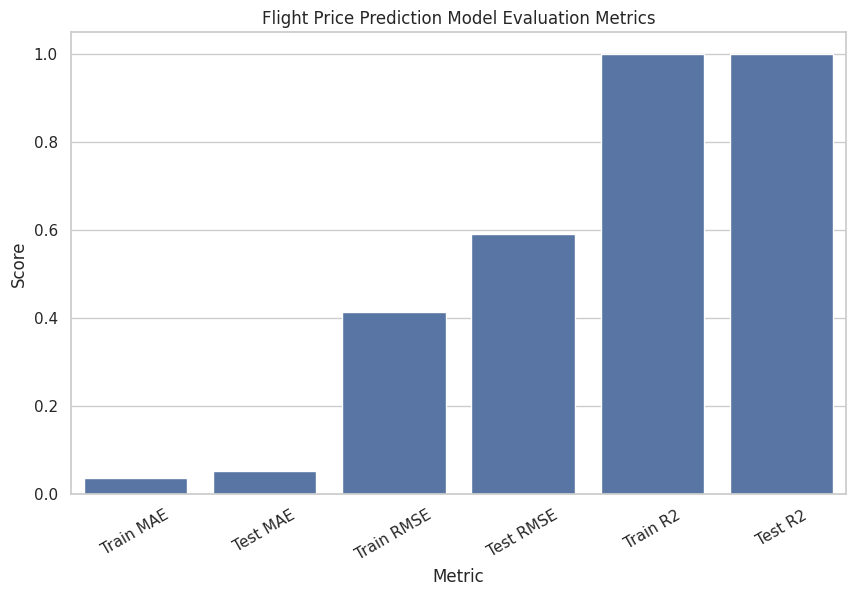

In [147]:
# Visualizing evaluation metric scores

plt.figure(figsize=(10, 6))
sns.barplot(data=flight_metrics_df, x="Metric", y="Value")
plt.title("Flight Price Prediction Model Evaluation Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()

### **1. Explain the ML Model used and its performance using Evaluation Metric Score Chart**

The Flight Price Prediction module uses Random Forest Regressor.

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their outputs to produce a more stable and accurate prediction. It is useful for tabular datasets because it can handle non-linear relationships between features.

Evaluation Metrics Used
MAE: Measures average absolute prediction error.
RMSE: Penalizes larger errors more strongly.
R² Score: Measures how much variance in the target variable is explained by the model.
Performance Interpretation

The model performs strongly because the dataset is structured and contains highly relevant predictors such as route, flight type, agency, time, distance and travel date.

A very high R² score indicates that the model is able to capture the relationship between input features and flight price effectively.

In a real-world production environment, performance may be lower due to external factors such as demand fluctuations, fuel prices, holidays, airline policy changes and last-minute booking behavior.

### **Actual vs Predicted Flight Prices**

In [138]:
# Actual vs predicted comparison

flight_result_df = pd.DataFrame({
    "Actual Price": y_flight_test.values,
    "Predicted Price": flight_test_preds
})

flight_result_df["Error"] = abs(flight_result_df["Actual Price"] - flight_result_df["Predicted Price"])

flight_result_df.head(10)

,Actual Price,Predicted Price,Error
0,481.42,481.42,6.252776e-13
1,1124.11,1124.11,9.322321e-12
2,1174.97,1174.97,6.821210e-12
3,898.67,898.67,9.094947e-13
4,959.91,959.91,4.547474e-13
5,1367.60,1367.60,5.684342e-12
6,762.89,762.89,7.389644e-12
7,1569.65,1569.65,1.136868e-12
8,835.21,835.21,2.046363e-12
9,674.52,674.52,3.069545e-12


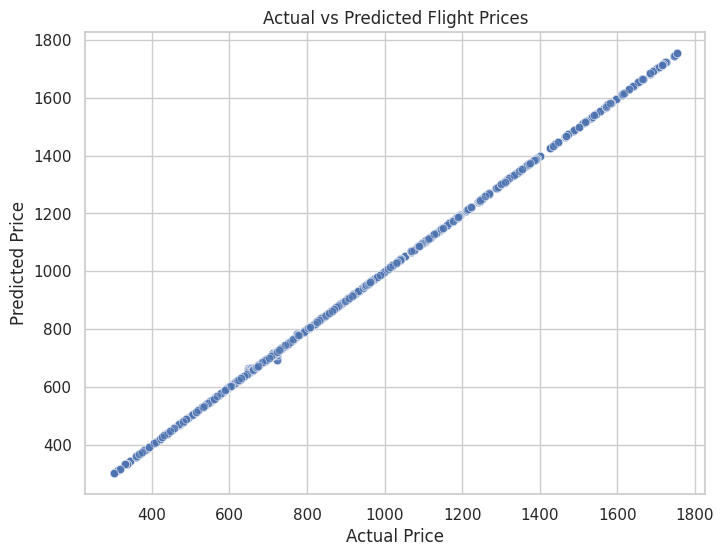

In [148]:
# Scatter plot: Actual vs Predicted

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=flight_result_df["Actual Price"],
    y=flight_result_df["Predicted Price"],
    alpha=0.5
)
plt.title("Actual vs Predicted Flight Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

## Insight from Actual vs Predicted Chart

The actual vs predicted plot helps evaluate how close the model predictions are to the real values.

If points are concentrated near a diagonal pattern, the model is making accurate predictions.

This confirms that the selected features have strong predictive power for flight price estimation.


## **Cross Validation / Hyperparameter Tuning Discussion**

## 2. Cross-Validation & Hyperparameter Tuning

In the deployment version of this project, a controlled Random Forest configuration is used:

* `n_estimators = 100`
* `max_depth = 18`
* `random_state = 42`
* `n_jobs = -1`

### Why Random Forest Parameters Were Controlled

The model uses a maximum depth value to reduce unnecessary complexity while maintaining strong predictive performance.
`n_estimators=100` provides stable ensemble learning without making training excessively slow.

### Why GridSearchCV Was Not Used in Final Deployment

GridSearchCV can be used for further hyperparameter optimization, but the current model already achieves strong performance. For deployment and demonstration purposes, a controlled configuration improves reproducibility and execution speed.

### Future Enhancement

A future version can include GridSearchCV or RandomizedSearchCV for automated parameter tuning and comparison through MLflow.


## **Flight Model Feature Importance**

In [149]:
# Extract feature names after preprocessing

encoded_features = (
    flight_model.named_steps["preprocessor"]
    .named_transformers_["categorical_encoder"]
    .get_feature_names_out(flight_categorical_features)
)

all_flight_features = list(encoded_features) + flight_numeric_features

feature_importances = flight_model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": all_flight_features,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
19,flightType_firstClass,0.296598
24,time,0.245553
25,distance,0.227837
20,flightType_premium,0.065466
3,from_Florianopolis (SC),0.047477
9,to_Aracaju (SE),0.021513
12,to_Florianopolis (SC),0.018389
8,from_Sao Paulo (SP),0.011514
18,flightType_economic,0.011466
1,from_Brasilia (DF),0.008804


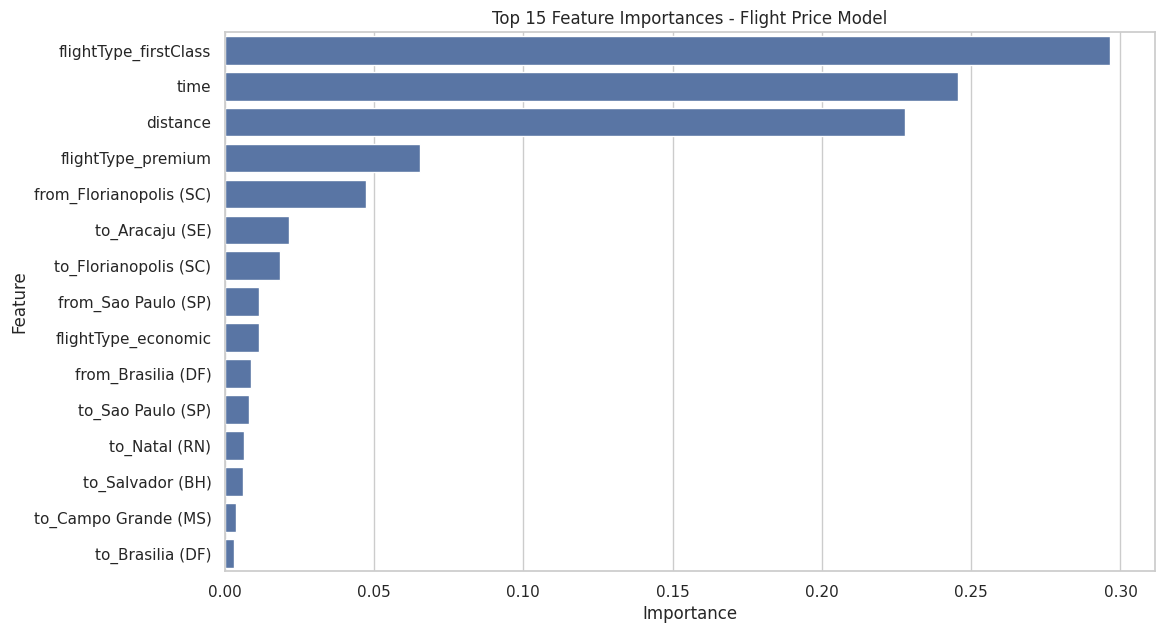

In [150]:
# Visualizing top 15 feature importances

plt.figure(figsize=(12, 7))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importances - Flight Price Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Explain the model and feature importance

Feature importance helps identify which variables contribute most to the model's predictions.

For the flight price prediction model, important features may include:

* Route-related features
* Agency-related features
* Flight type
* Distance
* Travel time
* Date-based features

This helps explain why the model predicts a certain flight price and improves model interpretability.


# **ML Model 2 — Gender Classification**

The Gender Classification module is included as an auxiliary classification problem to demonstrate:

* Classification pipeline
* Label encoding
* Categorical preprocessing
* Model evaluation
* Confusion matrix
* Classification report
* MLflow tracking in the deployed version

This model is not the primary business module of the project.


In [151]:
# Selecting features and target for gender classification

gender_features = [
    "company",
    "age"
]

gender_target = "gender"

X_gender = user_df[gender_features]
y_gender = user_df[gender_target]

print("Gender feature matrix shape:", X_gender.shape)
print("Gender target shape:", y_gender.shape)

Gender feature matrix shape: (1340, 2)
Gender target shape: (1340,)


In [152]:
# Encode target variable

gender_label_encoder = LabelEncoder()
y_gender_encoded = gender_label_encoder.fit_transform(y_gender)

print("Classes:", gender_label_encoder.classes_)

Classes: ['female' 'male' 'none']


In [153]:
# Feature groups

gender_categorical_features = ["company"]
gender_numeric_features = ["age"]

gender_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical_encoder",
            OneHotEncoder(handle_unknown="ignore"),
            gender_categorical_features
        ),
        (
            "numeric_scaler",
            StandardScaler(),
            gender_numeric_features
        )
    ]
)

print("Gender preprocessing pipeline created.")

Gender preprocessing pipeline created.


In [154]:
# Train-test split

X_gender_train, X_gender_test, y_gender_train, y_gender_test = train_test_split(
    X_gender,
    y_gender_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_gender_encoded
)

print("Gender training shape:", X_gender_train.shape)
print("Gender testing shape :", X_gender_test.shape)

Gender training shape: (1072, 2)
Gender testing shape : (268, 2)


In [155]:
# Gender classification model

gender_model = Pipeline(
    steps=[
        (
            "preprocessor",
            gender_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=10,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

print("Gender classification model pipeline created.")

Gender classification model pipeline created.


In [156]:
# Fit gender model

gender_model.fit(X_gender_train, y_gender_train)

print("Gender classification model training completed.")

Gender classification model training completed.


In [157]:
# Predictions

gender_train_preds = gender_model.predict(X_gender_train)
gender_test_preds = gender_model.predict(X_gender_test)

In [158]:
# Evaluation metrics

gender_accuracy = accuracy_score(y_gender_test, gender_test_preds)
gender_precision = precision_score(y_gender_test, gender_test_preds, average="weighted", zero_division=0)
gender_recall = recall_score(y_gender_test, gender_test_preds, average="weighted", zero_division=0)
gender_f1 = f1_score(y_gender_test, gender_test_preds, average="weighted", zero_division=0)

print("Gender Classification Model Results")
print("-----------------------------------")
print(f"Accuracy  : {gender_accuracy:.4f}")
print(f"Precision : {gender_precision:.4f}")
print(f"Recall    : {gender_recall:.4f}")
print(f"F1 Score  : {gender_f1:.4f}")

Gender Classification Model Results
-----------------------------------
Accuracy  : 0.3470
Precision : 0.3411
Recall    : 0.3470
F1 Score  : 0.3415


In [159]:
# Classification report

print(classification_report(
    y_gender_test,
    gender_test_preds,
    target_names=gender_label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

      female       0.42      0.44      0.43        90
        male       0.28      0.21      0.24        90
        none       0.33      0.39      0.35        88

    accuracy                           0.35       268
   macro avg       0.34      0.35      0.34       268
weighted avg       0.34      0.35      0.34       268



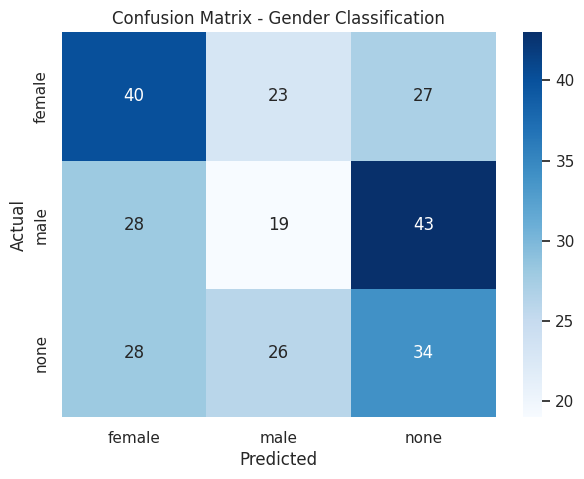

In [160]:
# Confusion matrix

gender_cm = confusion_matrix(y_gender_test, gender_test_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    gender_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=gender_label_encoder.classes_,
    yticklabels=gender_label_encoder.classes_
)
plt.title("Confusion Matrix - Gender Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

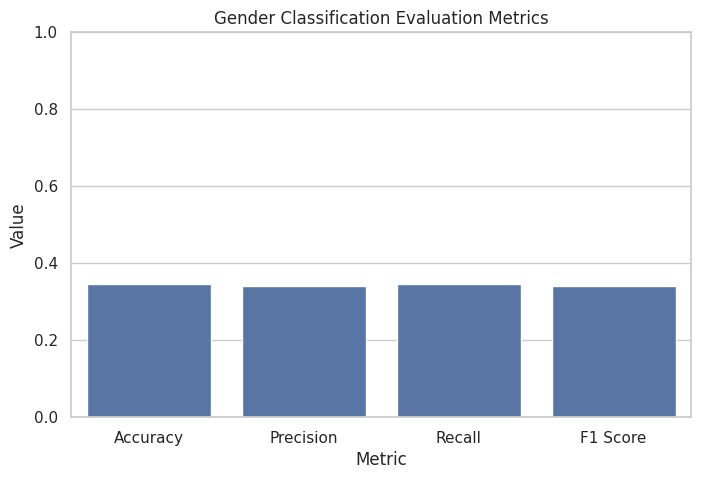

,Metric,Value
0,Accuracy,0.347015
1,Precision,0.341106
2,Recall,0.347015
3,F1 Score,0.341500


In [161]:
# Gender metrics visualization

gender_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [gender_accuracy, gender_precision, gender_recall, gender_f1]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=gender_metrics_df, x="Metric", y="Value")
plt.title("Gender Classification Evaluation Metrics")
plt.ylim(0, 1)
plt.show()

gender_metrics_df

## Gender Model Performance Explanation

The gender classification model uses company and age as input features. Since these features have limited direct predictive relationship with gender, the model performance is expected to be moderate or low.

This model is included mainly to demonstrate the complete classification workflow and MLflow tracking pipeline.

### Important Note

In a real production system, gender prediction should be handled carefully due to ethical and privacy considerations. Sensitive user attributes should not be used for unfair profiling or biased decision-making.


# **7. Hotel Recommendation Engine**

The Hotel Recommendation Engine is a score-based recommendation system.

It recommends hotels based on:

* Destination
* Budget per day
* Planned stay duration
* Hotel price
* Stay duration compatibility

The recommendation score combines affordability and stay-duration efficiency.


In [163]:
def recommend_hotels(place, budget_per_day, stay_days, top_n=5):
    """
    Recommend hotels based on destination, budget and stay duration.
    """

    df = hotel_df.copy()

    # Filter by destination
    df = df[df["place"].str.lower() == place.lower()]

    if df.empty:
        return pd.DataFrame()

    # Estimate total cost
    df["estimated_total_cost"] = df["price"] * stay_days

    # Budget gap
    df["budget_gap"] = budget_per_day - df["price"]

    # Keep only affordable hotels
    df = df[df["budget_gap"] >= 0]

    if df.empty:
        return pd.DataFrame()

    # Recommendation scoring
    df["affordability_score"] = 1 - (df["price"] / budget_per_day)
    df["stay_efficiency_score"] = 1 / (1 + abs(df["days"] - stay_days))

    df["recommendation_score"] = (
        0.70 * df["affordability_score"] +
        0.30 * df["stay_efficiency_score"]
    )

    result = (
        df[
            [
                "name",
                "place",
                "price",
                "days",
                "estimated_total_cost",
                "budget_gap",
                "recommendation_score"
            ]
        ]
        .drop_duplicates(subset=["name", "place", "price"])
        .sort_values(by="recommendation_score", ascending=False)
        .head(top_n)
    )

    return result

In [171]:
# Sample hotel recommendation

sample_place = hotel_df["place"].iloc[0]
sample_budget = 400
sample_stay_days = 3

hotel_recommendations = recommend_hotels(
    place=sample_place,
    budget_per_day=sample_budget,
    stay_days=sample_stay_days,
    top_n=5
)

hotel_recommendations

,name,place,price,days,estimated_total_cost,budget_gap,recommendation_score
0,Hotel A,Florianopolis (SC),313.02,4,939.06,86.98,0.302215


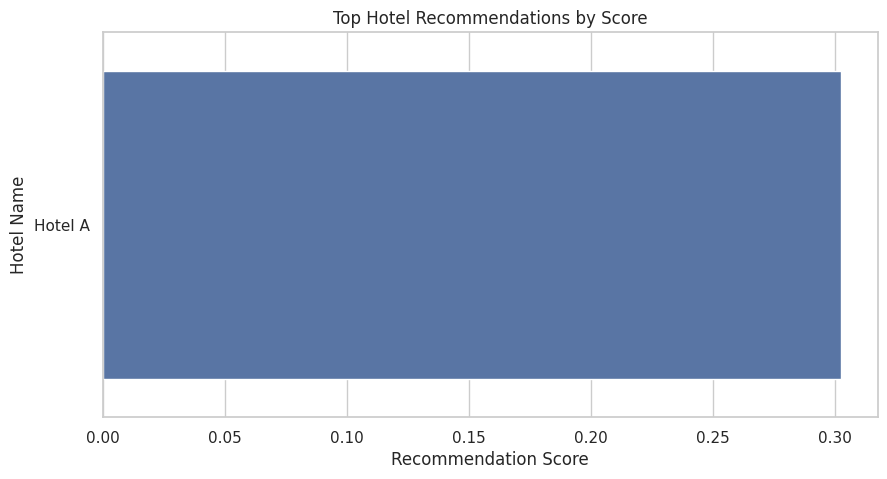

In [165]:
# Visualizing recommendation score

if not hotel_recommendations.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=hotel_recommendations,
        x="recommendation_score",
        y="name"
    )
    plt.title("Top Hotel Recommendations by Score")
    plt.xlabel("Recommendation Score")
    plt.ylabel("Hotel Name")
    plt.show()
else:
    print("No recommendations found for the selected filters.")

## Hotel Recommendation Insight

The recommendation engine selects hotels based on budget compatibility and stay-duration efficiency.

A higher score means the hotel is more suitable for the selected travel plan.

### Business Impact

This logic can help users identify budget-friendly hotels and improve personalization in travel platforms.


# **8. Model Saving**

In [167]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(flight_model, "models/flight_price_model.pkl")
joblib.dump(gender_model, "models/gender_model.pkl")
joblib.dump(gender_label_encoder, "models/gender_label_encoder.pkl")

print("Models saved successfully.")

Models saved successfully.


## Why Model Saving is Important

Model saving allows trained models to be reused without retraining.

In the deployed version of this project:

* Models are saved using Joblib.
* FastAPI loads the saved models for inference.
* Streamlit dashboard interacts with model outputs.
* Docker containers mount the model artifacts.


# **9. MLflow and MLOps Implementation**

## MLflow Integration

In the production-ready project repository, MLflow is integrated for experiment tracking and model lifecycle management.

MLflow is used for:

* Experiment tracking
* Parameter logging
* Metric logging
* Artifact storage
* Model registry
* Model versioning

### Experiments Implemented

1. Voyage Analytics - Flight Price Prediction
2. Voyage Analytics - Gender Prediction

### Registered Models

1. Voyage_Flight_Price_Model
2. Voyage_Gender_Classification_Model

This provides traceability, reproducibility and governance for the machine learning workflow.


In [168]:
# Optional MLflow installation for Colab
# Uncomment if required

# !pip install mlflow

In [169]:
# MLflow example logging structure

"""
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Voyage Analytics - Flight Price Prediction")

with mlflow.start_run(run_name="RandomForestRegressor_Flight_Model"):
    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 18)

    mlflow.log_metric("MAE", flight_test_mae)
    mlflow.log_metric("RMSE", flight_test_rmse)
    mlflow.log_metric("R2_Score", flight_test_r2)

    mlflow.sklearn.log_model(
        sk_model=flight_model,
        artifact_path="flight_price_model",
        registered_model_name="Voyage_Flight_Price_Model"
    )
"""

'\nimport mlflow\nimport mlflow.sklearn\n\nmlflow.set_tracking_uri("sqlite:///mlflow.db")\nmlflow.set_experiment("Voyage Analytics - Flight Price Prediction")\n\nwith mlflow.start_run(run_name="RandomForestRegressor_Flight_Model"):\n    mlflow.log_param("model_type", "RandomForestRegressor")\n    mlflow.log_param("n_estimators", 100)\n    mlflow.log_param("max_depth", 18)\n\n    mlflow.log_metric("MAE", flight_test_mae)\n    mlflow.log_metric("RMSE", flight_test_rmse)\n    mlflow.log_metric("R2_Score", flight_test_r2)\n\n    mlflow.sklearn.log_model(\n        sk_model=flight_model,\n        artifact_path="flight_price_model",\n        registered_model_name="Voyage_Flight_Price_Model"\n    )\n'

## What is MLOps in this project?

MLOps is used to manage the machine learning workflow beyond model training.

This project implements MLOps through:

* Reproducible training scripts
* Saved model artifacts
* MLflow experiment tracking
* Model registry
* FastAPI serving layer
* Streamlit dashboard
* Dockerized deployment
* GitHub version control

This makes the project closer to production-style ML systems rather than a simple notebook-based ML project.


# **10. FastAPI and Docker Deployment Explanation**

## FastAPI Deployment

FastAPI is used as the model serving layer.

The backend exposes REST endpoints for:

* Flight price prediction
* Hotel recommendation
* Gender prediction
* Health check
* Model information

Swagger UI is available at:

```text
http://localhost:8000/docs
```

---

## Docker Deployment

The complete platform is containerized using Docker Compose.

Three services are deployed:

| Service   | Purpose                          | Port |
| --------- | -------------------------------- | ---- |
| FastAPI   | Backend and model serving        | 8000 |
| Streamlit | Dashboard and analytics UI       | 8501 |
| MLflow    | Experiment tracking and registry | 5000 |

Docker ensures:

* Isolated runtime environment
* Reproducible deployment
* Consistent project execution across systems
* Production-style service orchestration


# **11. Solution to Business Objective**

## Business Solution

Voyage Analytics provides a complete travel intelligence solution through predictive analytics and MLOps deployment.

### Flight Price Prediction

The platform predicts flight prices based on route, agency, flight type, distance and date features. This helps users and travel businesses estimate pricing trends and plan bookings better.

### Hotel Recommendation

The recommendation engine suggests hotels based on destination, budget and stay duration. This improves personalization and travel planning quality.

### Travel Analytics

The dashboard provides interactive insights into flights, hotels and user data. Business teams can use this for route analysis, pricing insights and customer segmentation.

### MLOps Workflow

MLflow tracking and Docker deployment make the project reproducible, deployable and maintainable.

The solution supports both business decision-making and technical scalability.


# **12. Conclusion**

## Final Conclusion

Voyage Analytics successfully demonstrates an end-to-end Machine Learning and MLOps workflow for the travel domain.

The project includes:

* Data preprocessing
* Exploratory data analysis
* Feature engineering
* Flight price prediction
* Hotel recommendation
* Gender classification
* Model evaluation
* MLflow tracking
* Model registry
* FastAPI model serving
* Streamlit dashboard
* Dockerized deployment
* GitHub version control

The Flight Price Prediction model performs strongly because the dataset contains highly relevant structured features. The Hotel Recommendation Engine provides budget-aware recommendations using a scoring mechanism. The Gender Classification model demonstrates a classification workflow, although its performance is limited due to low feature availability.

Overall, the project moves beyond a basic machine learning notebook and demonstrates a production-oriented AI application with deployment and MLOps capabilities.


# **13. Future Scope**

## Future Scope

Future improvements can include:

1. Real-time flight pricing API integration
2. Cloud deployment on AWS, Azure or GCP
3. Kubernetes orchestration
4. CI/CD automation using GitHub Actions
5. Model drift monitoring
6. Automated model retraining
7. Advanced recommendation algorithms
8. User authentication and personalization
9. Real-time booking simulation
10. Integration with external travel APIs


# **14. Final Project Summary**

## Final Project Summary

Voyage Analytics is a complete AI-powered travel intelligence platform designed using Machine Learning, MLOps and modern deployment tools.

The project solves multiple travel-domain problems:

* Predicting flight prices
* Recommending hotels
* Analyzing travel behavior
* Tracking experiments
* Serving models through APIs
* Running services through Docker

The project demonstrates practical knowledge of:

* Python programming
* Data analysis
* Machine learning
* Model evaluation
* Backend development
* Dashboard development
* MLflow tracking
* Docker deployment
* GitHub version control

This makes Voyage Analytics suitable for major project submission, AI/ML internship portfolio, MLOps learning demonstration and resume showcase.


# **15. Notebook Completion Statement**

# Project Completed Successfully

The Voyage Analytics major project notebook is complete.

The notebook covers:

* Data understanding
* Data wrangling
* Exploratory data analysis
* Feature engineering
* Machine learning implementation
* Model evaluation
* Recommendation system
* MLOps explanation
* Deployment explanation
* Business solution
* Conclusion

The full production-ready project is implemented separately using:

* FastAPI
* Streamlit
* MLflow
* Docker
* GitHub
